In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import ast


In [13]:
df = pd.read_csv("/kaggle/input/datasets/shashk99/sinhala-dataset/Sinhala/data/sold_test.csv")

df.head()


,post_id,text,tokens,rationales,label
0,995411387894542336,තේ නෙවෙයි තෝ බීලා ඉන්නෙ ගිනි වතුර,තේ නෙවෙයි තෝ බීලා ඉන්නෙ ගිනි වතුර,[],NOT
1,1128238706303864832,@USER තුනක් ඕනේ නෑ එකක් ගැහුවනම් ඇති ලංකාවට ආප...,@USER තුනක් ඕනේ නෑ එකක් ගැහුවනම් ඇති ලංකාවට ආප...,[],NOT
2,1290554471714496514,"@USER , @USER @USER ටහුඩු ඒකි තනියම ජීවත් වෙ...","@USER , @USER @USER ටහුඩු ඒකි තනියම ජීවත් වෙන්...",[],NOT
3,909459929446182913,@USER මර්විනුත් මුද්දරයක් වෙයිද දන්නේ නැ,@USER මර්විනුත් මුද්දරයක් වෙයිද දන්නේ නැ,[],NOT
4,1305480579375198208,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,@USER ගොසිප් පීපල් නෙමේ හුත්තො . තෝ වගේ හොරෙක්...,"[0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",OFF


In [14]:
df.shape


(2500, 5)

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   post_id     2500 non-null   int64 
 1   text        2500 non-null   object
 2   tokens      2500 non-null   object
 3   rationales  2500 non-null   object
 4   label       2500 non-null   object
dtypes: int64(1), object(4)
memory usage: 97.8+ KB


In [16]:
df.isnull().sum()


post_id       0
text          0
tokens        0
rationales    0
label         0
dtype: int64

In [17]:
# 6. Label Distribution
df['label'].value_counts()


label
NOT    1485
OFF    1015
Name: count, dtype: int64

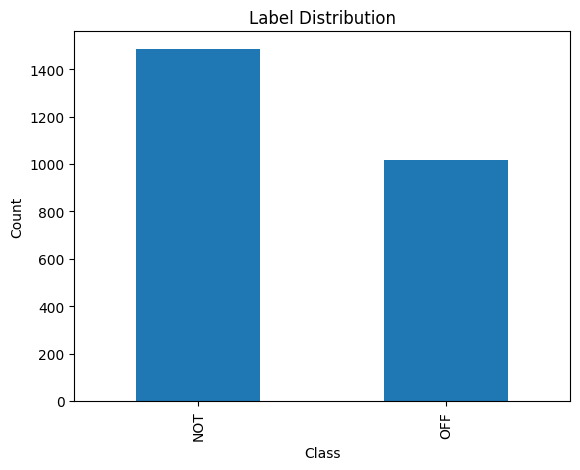

In [18]:
df['label'].value_counts().plot(kind='bar')

plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [19]:
# 7. Convert Token Columns
df['tokens'] = df['tokens'].apply(lambda x: str(x).split())

df['rationales'] = df['rationales'].apply(ast.literal_eval)


In [20]:
# 8. Extract Offensive Words
def extract_offensive_words(row):
    
    tokens = row['tokens']
    rationales = row['rationales']
    
    offensive_words = []
    
    for t,r in zip(tokens,rationales):
        if r == 1:
            offensive_words.append(t)
            
    return offensive_words


In [21]:
df['offensive_words'] = df.apply(extract_offensive_words, axis=1)

df[['text','offensive_words']].head()


,text,offensive_words
0,තේ නෙවෙයි තෝ බීලා ඉන්නෙ ගිනි වතුර,[]
1,@USER තුනක් ඕනේ නෑ එකක් ගැහුවනම් ඇති ලංකාවට ආප...,[]
2,"@USER , @USER @USER ටහුඩු ඒකි තනියම ජීවත් වෙ...",[]
3,@USER මර්විනුත් මුද්දරයක් වෙයිද දන්නේ නැ,[]
4,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,"[හුත්තො, තෝ]"


In [22]:
# 9. Offensive Word Frequency
off_words = df['offensive_words'].explode()

off_words.value_counts().head(20)


offensive_words
තෝ          93
ගොන්        63
පුක         60
හැත්ත       55
සක්කිලි     50
පොන්න       44
නොදකින්     41
තොපි        40
රෙද්ද       37
මෝඩ         35
යකෝ         35
බිජ්ජ       35
අවජාතක      32
පකෝ         32
වේස         31
පයිය        29
තොට         28
කාලකණ්ණි    28
හුජ්ජ       25
වේසි        20
Name: count, dtype: int64

In [23]:
# 10. Word Frequency in Dataset
all_words = " ".join(df['text']).lower().split()

word_freq = Counter(all_words)

word_freq.most_common(20)


[('@user', 2106),
 ('මේ', 392),
 ('එක', 331),
 ('වගේ', 255),
 ('url', 251),
 ('නෑ', 248),
 ('ඒ', 245),
 ('කියලා', 208),
 ('නම්', 174),
 ('·', 168),
 ('එකක්', 166),
 ('දැන්', 162),
 ('ඉන්න', 157),
 ('කරන්න', 155),
 ('.', 149),
 ('කියල', 140),
 ('මට', 137),
 ('මම', 136),
 ('අපි', 136),
 ('යකෝ', 134)]

In [24]:
# 11. Text Length Analysis

df['text_length'] = df['text'].apply(len)

df['text_length'].describe()


count    2500.000000
mean      120.020000
std        86.877829
min        19.000000
25%        53.750000
50%        98.000000
75%       152.000000
max       615.000000
Name: text_length, dtype: float64

In [25]:
# 12. Compare Offensive vs Non-Offensive Length
df.groupby('label')['text_length'].mean()


label
NOT    111.753535
OFF    132.114286
Name: text_length, dtype: float64

In [26]:
# 13. Offensive Word Count Per Post
df['off_word_count'] = df['offensive_words'].apply(len)

df[['text','off_word_count']].head()


,text,off_word_count
0,තේ නෙවෙයි තෝ බීලා ඉන්නෙ ගිනි වතුර,0
1,@USER තුනක් ඕනේ නෑ එකක් ගැහුවනම් ඇති ලංකාවට ආප...,0
2,"@USER , @USER @USER ටහුඩු ඒකි තනියම ජීවත් වෙ...",0
3,@USER මර්විනුත් මුද්දරයක් වෙයිද දන්නේ නැ,0
4,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,2


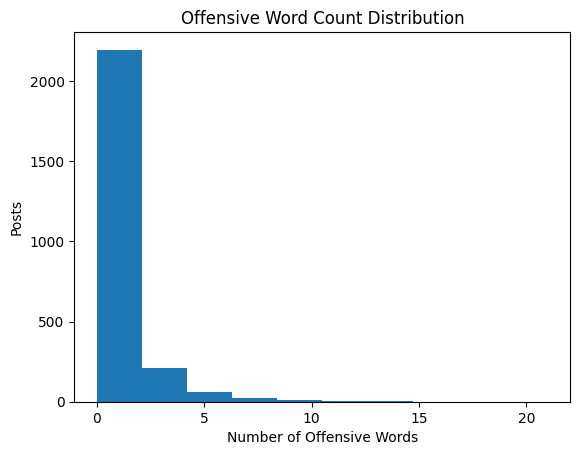

In [27]:
# 14. Distribution of Offensive Words
df['off_word_count'].plot(kind='hist', bins=10)

plt.title("Offensive Word Count Distribution")
plt.xlabel("Number of Offensive Words")
plt.ylabel("Posts")
plt.show()


In [28]:
# 15. Separate Offensive Posts
offensive_df = df[df['label']=="OFF"]

offensive_df.head()


,post_id,text,tokens,rationales,label,offensive_words,text_length,off_word_count
4,1305480579375198208,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,"[@USER, ගොසිප්, පීපල්, නෙමේ, හුත්තො, ., තෝ, වග...","[0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",OFF,"[හුත්තො, තෝ]",83,2
12,861077416835338241,මෙහෙවු කැබිනට් එකක මං ඉදලම නෑ.. කැබිනට් ප්‍රකා...,"[මෙහෙවු, කැබිනට්, එකක, මං, ඉදලම, නෑ, ., ., කැබ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...",OFF,"[පිස්සු, කෙලින්නේ]",113,2
13,1038766137415266305,"දේශපාලුවෝ බහුතරය පූජකයන්ට කැමතියි, මොකද ඕන ගොන...","[දේශපාලුවෝ, බහුතරය, පූජකයන්ට, කැමතියි, ,, මොකද...","[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, ...",OFF,"[ගොන්, ගොන්]",178,2
14,1143097359393611777,@USER මේ කාලකන්නි දේශපාලඥයන්ගේ අමන ප්‍රකාශ නිස...,"[@USER, මේ, කාලකන්නි, දේශපාලඥයන්ගේ, අමන, ප්‍රක...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",OFF,"[පකයෝ, පකයො]",226,2
20,635374020834168832,යකෝ හුජ්ජ පාරක් නිදහසේවත් දාන්න තැනක් නෑනේ ෂිට...,"[යකෝ, හුජ්ජ, පාරක්, නිදහසේවත්, දාන්න, තැනක්, න...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",OFF,"[යකෝ, හුජ්ජ]",90,2


In [29]:
# 16. Create Offensive Word Dataset
offensive_dataset = offensive_df[['text','offensive_words']]

offensive_dataset.head()


,text,offensive_words
4,@USER ගොසිප් පීපල් නෙමේ හුත්තො. තෝ වගේ හොරෙක්ට...,"[හුත්තො, තෝ]"
12,මෙහෙවු කැබිනට් එකක මං ඉදලම නෑ.. කැබිනට් ප්‍රකා...,"[පිස්සු, කෙලින්නේ]"
13,"දේශපාලුවෝ බහුතරය පූජකයන්ට කැමතියි, මොකද ඕන ගොන...","[ගොන්, ගොන්]"
14,@USER මේ කාලකන්නි දේශපාලඥයන්ගේ අමන ප්‍රකාශ නිස...,"[පකයෝ, පකයො]"
20,යකෝ හුජ්ජ පාරක් නිදහසේවත් දාන්න තැනක් නෑනේ ෂිට...,"[යකෝ, හුජ්ජ]"


In [30]:
# 17. Add Stereotype Annotation Column
df['stereotype'] = ""


In [41]:
# 18. Save Processed Dataset
df.to_csv("/processed_sold_dataset.csv", index=False)


In [32]:
# 19. Save Offensive Word List
off_words.value_counts().to_csv("/offensive_word_frequency.csv")


# **Analysis** 

In [53]:
!wget https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansSinhala/NotoSansSinhala-Regular.ttf


--2026-03-08 08:38:29--  https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansSinhala/NotoSansSinhala-Regular.ttf
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/notofonts/noto-fonts/raw/main/hinted/ttf/NotoSansSinhala/NotoSansSinhala-Regular.ttf [following]
--2026-03-08 08:38:30--  https://github.com/notofonts/noto-fonts/raw/main/hinted/ttf/NotoSansSinhala/NotoSansSinhala-Regular.ttf
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoSansSinhala/NotoSansSinhala-Regular.ttf [following]
--2026-03-08 08:38:30--  https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoSansSinhala/NotoSansSinhala-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent

In [56]:

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/kaggle/working/NotoSansSinhala-Regular.ttf"   # correct path

fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()


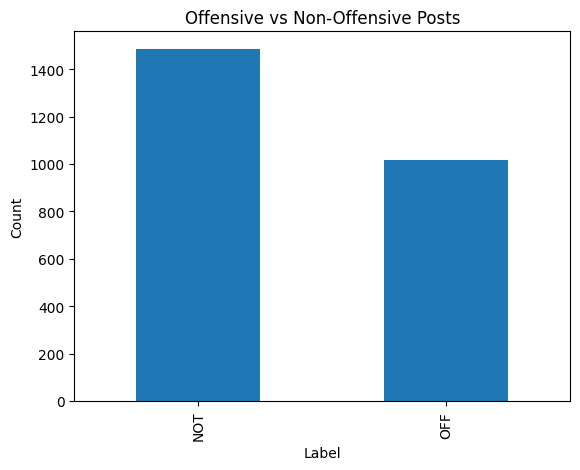

In [33]:
# 1. Label Distribution (Bar Chart)

# Shows how many OFF vs NOT posts exist.
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Offensive vs Non-Offensive Posts")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


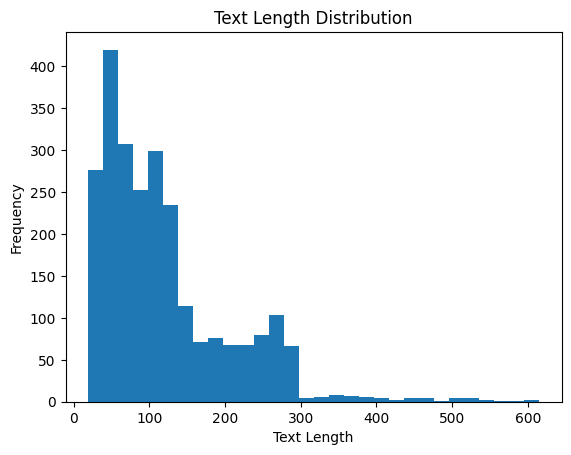

In [34]:
# 2. Text Length Distribution (Histogram)
df['text_length'] = df['text'].apply(len)

plt.hist(df['text_length'], bins=30)

plt.title("Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


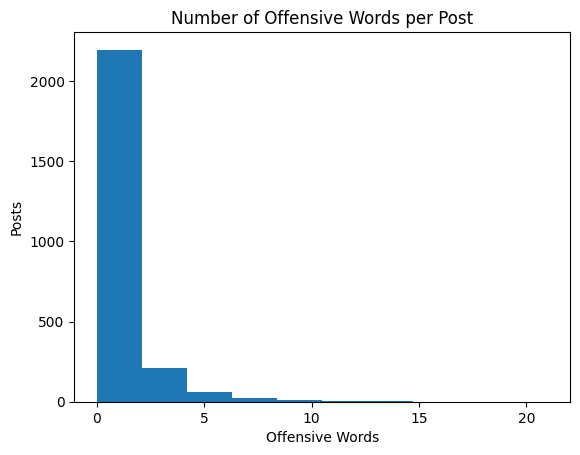

In [35]:
# 3. Offensive Word Count Distribution
df['off_word_count'] = df['offensive_words'].apply(len)

plt.hist(df['off_word_count'], bins=10)

plt.title("Number of Offensive Words per Post")
plt.xlabel("Offensive Words")
plt.ylabel("Posts")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 70 (F) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 114 (r) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 101 (e) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 113 (

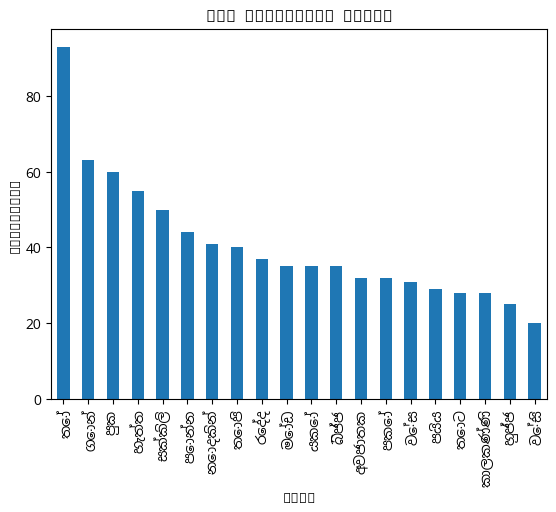

In [57]:
# 4. Top Offensive Words (Bar Chart)
from collections import Counter

off_words = df['offensive_words'].explode()

top_words = off_words.value_counts().head(20)

top_words.plot(kind='bar')

plt.title("Top Offensive Words")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.show()


In [59]:
# 5. Word Cloud Visualization
!pip install wordcloud


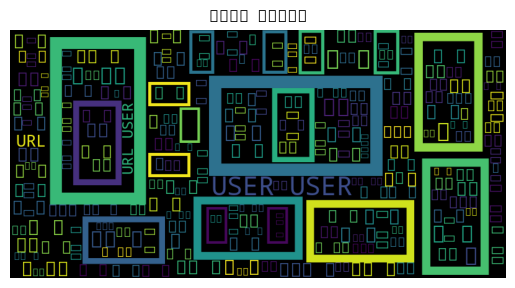

In [61]:
from wordcloud import WordCloud

text = " ".join(df['text'])

wordcloud = WordCloud(width=800,height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()


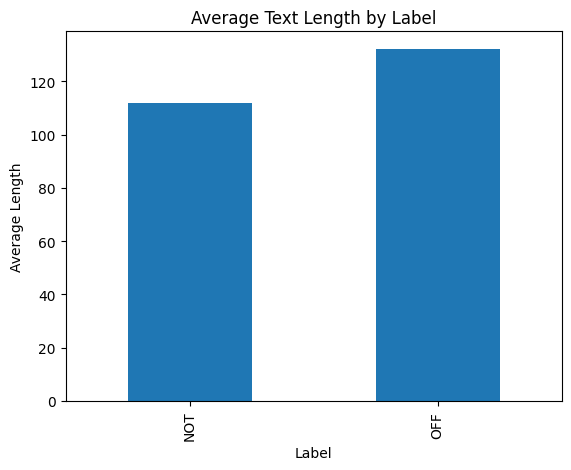

In [39]:
# 6. Offensive vs Non-Offensive Text Length
df.groupby('label')['text_length'].mean().plot(kind='bar')

plt.title("Average Text Length by Label")
plt.xlabel("Label")
plt.ylabel("Average Length")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 84 (T) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 79 (O) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 102 (f

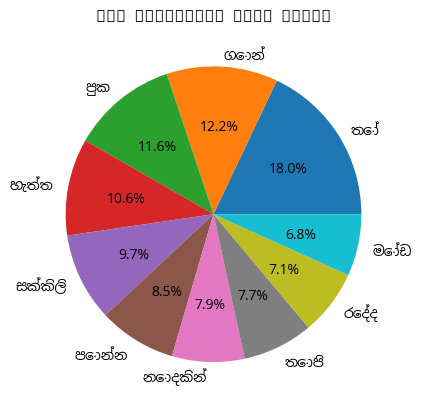

In [62]:
# 7. Offensive Word Frequency Pie Chart
top_words.head(10).plot(kind='pie', autopct='%1.1f%%')

plt.title("Top Offensive Word Share")
plt.ylabel("")
plt.show()
